In [3]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

FEATURES_DIR  = os.path.join("..", config.FEATURES_DATA_DIR)
MODELS_DIR    = os.path.join("..", config.MODELS_DIR)
METRICS_DIR   = os.path.join("..", config.OUTPUTS_METRICS)
PLOTS_DIR     = os.path.join("..", config.OUTPUTS_PLOTS)
CITIES        = list(config.CITIES.keys())
SEED          = config.SEED
DAYTIME_THR   = config.DAYTIME_THR
TRAIN_FRAC    = config.TRAIN_FRAC
VAL_FRAC      = config.VAL_FRAC

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

print("✅ Imports ready")

✅ Imports ready


In [4]:
feat_json = os.path.join(METRICS_DIR, "selected_features.json")
with open(feat_json) as f:
    feat_cfg = json.load(f)

TARGET = feat_cfg["target"]

# ── Manually define safe features for tabular baselines ──────────
# These are physics-based features that do NOT encode GHI directly.
# Sequence models (LSTM, SNN) will use the full feature set including
# lags — but tabular models must use only these.

SELECTED_FEATURES = [
    # Solar physics — strongest predictors without encoding GHI
    "clear_sky_ghi",       # theoretical maximum irradiance
    "solar_elevation",     # sun height angle
    "cos_zenith",          # cosine of solar zenith

    # Cyclical time encodings
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "month_sin",
    "month_cos",

    # Weather features
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "precipitation",

    # Daytime flag
    "is_daytime",
    "is_daytime_clear_sky",

    # Interaction terms (no GHI involved)
    "temp_x_humidity",
    "wind_x_humidity",
]

print(f"📋 Safe features for baseline : {len(SELECTED_FEATURES)}")
print(f"\n   Features being used:")
for f in SELECTED_FEATURES:
    print(f"   • {f}")

city_dfs = {}
print(f"\n📂 Loading feature CSVs...")
for city in CITIES:
    path = os.path.join(FEATURES_DIR, f"{city}_features.csv")
    df   = pd.read_csv(path, index_col="datetime", parse_dates=True)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    city_dfs[city] = df
    print(f"  ✅ {city:<14}  {df.shape}")

📋 Safe features for baseline : 18

   Features being used:
   • clear_sky_ghi
   • solar_elevation
   • cos_zenith
   • hour_sin
   • hour_cos
   • doy_sin
   • doy_cos
   • month_sin
   • month_cos
   • temperature
   • humidity
   • wind_speed
   • pressure
   • precipitation
   • is_daytime
   • is_daytime_clear_sky
   • temp_x_humidity
   • wind_x_humidity

📂 Loading feature CSVs...
  ✅ riyadh          (26232, 58)
  ✅ cairo           (26232, 58)
  ✅ istanbul        (26232, 58)
  ✅ new_delhi       (26232, 58)
  ✅ dubai           (26232, 58)
  ✅ london          (26232, 58)
  ✅ sydney          (26232, 58)
  ✅ tokyo           (26232, 58)
  ✅ los_angeles     (26232, 58)
  ✅ nairobi         (26232, 58)


In [5]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    label: str = "") -> dict:
    """Full evaluation suite — RMSE, MAE, MAPE, R², Skill Score."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)

    # MAPE — avoid division by zero
    mask  = y_true > 1.0
    mape  = np.mean(np.abs(
        (y_true[mask] - y_pred[mask]) / y_true[mask]
    )) * 100 if mask.sum() > 0 else np.nan

    metrics = {
        "model" : label,
        "RMSE"  : round(rmse,  3),
        "MAE"   : round(mae,   3),
        "MAPE"  : round(mape,  3),
        "R2"    : round(r2,    4),
    }
    return metrics


def chronological_split(df: pd.DataFrame,
                         train_frac: float = TRAIN_FRAC,
                         val_frac:   float = VAL_FRAC):
    """Split preserving time order — no data leakage."""
    n         = len(df)
    train_end = int(n * train_frac)
    val_end   = int(n * (train_frac + val_frac))
    return (
        df.iloc[:train_end],
        df.iloc[train_end:val_end],
        df.iloc[val_end:]
    )


def prepare_Xy(df: pd.DataFrame, features: list, target: str):
    """Extract X and y arrays from dataframe."""
    available = [f for f in features if f in df.columns]
    X = df[available].values.astype(np.float32)
    y = df[target].values.astype(np.float32)
    return X, y, available


print("✅ Utilities defined")
print(f"   Train : {int(TRAIN_FRAC*100)}%  "
      f"Val : {int(VAL_FRAC*100)}%  "
      f"Test : {int((1-TRAIN_FRAC-VAL_FRAC)*100)}%")

✅ Utilities defined
   Train : 72%  Val : 8%  Test : 20%


In [6]:
def persistence_baseline(df: pd.DataFrame, target: str) -> np.ndarray:
    """
    Persistence model: predict next hour = current hour.
    This is the standard naive baseline for time-series forecasting.
    """
    return df[target].shift(1).fillna(method="bfill").values


def climatology_baseline(train_df: pd.DataFrame,
                          test_df:  pd.DataFrame,
                          target:   str) -> np.ndarray:
    """
    Climatology model: predict mean GHI for same (month, local_hour).
    Uses historical averages — strong baseline for solar data.
    """
    train = train_df.copy()
    test  = test_df.copy()

    train["month"]      = train.index.month
    train["local_hour"] = train.index.hour
    test["month"]       = test.index.month
    test["local_hour"]  = test.index.hour

    clim = (train.groupby(["month", "local_hour"])[target]
                 .mean()
                 .reset_index()
                 .rename(columns={target: "clim_pred"}))

    merged = test.merge(clim, on=["month", "local_hour"], how="left")
    merged["clim_pred"] = merged["clim_pred"].fillna(0.0)
    return merged["clim_pred"].values


print("✅ Persistence and climatology baselines defined")

✅ Persistence and climatology baselines defined


In [7]:
ML_MODELS = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "RandomForest": RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = 15,
        min_samples_leaf = 5,
        n_jobs           = -1,
        random_state     = SEED,
    ),

    "XGBoost": XGBRegressor(
        n_estimators     = 500,
        max_depth        = 7,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        random_state     = SEED,
        n_jobs           = -1,
        verbosity        = 0,
        eval_metric      = "rmse",
    ),
}

print(f"✅ {len(ML_MODELS)} ML models defined:")
for name in ML_MODELS:
    print(f"   • {name}")

✅ 4 ML models defined:
   • LinearRegression
   • Ridge
   • RandomForest
   • XGBoost


In [8]:
all_results = []

print("=" * 65)
print("  TRAINING BASELINE MODELS — ALL CITIES")
print("=" * 65)

for city in CITIES:
    print(f"\n{'─'*55}")
    print(f"  📍 {city.upper()}")
    print(f"{'─'*55}")

    df          = city_dfs[city]
    train_df, val_df, test_df = chronological_split(df)
    train_val   = pd.concat([train_df, val_df])   # for final ML fit

    X_train, y_train, feats = prepare_Xy(train_val, SELECTED_FEATURES, TARGET)
    X_test,  y_test,  _     = prepare_Xy(test_df,   feats,             TARGET)

    # Scale
    scaler   = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    city_results = []

    # ── Persistence ───────────────────────────────────────────────
    pers_pred = persistence_baseline(test_df, TARGET)
    m = compute_metrics(y_test, pers_pred, "Persistence")
    m["city"] = city
    city_results.append(m)
    print(f"  Persistence   RMSE={m['RMSE']:>8.3f}  MAE={m['MAE']:>8.3f}  R²={m['R2']:>7.4f}")

    # ── Climatology ───────────────────────────────────────────────
    clim_pred = climatology_baseline(train_val, test_df, TARGET)
    m = compute_metrics(y_test, clim_pred, "Climatology")
    m["city"] = city
    city_results.append(m)
    print(f"  Climatology   RMSE={m['RMSE']:>8.3f}  MAE={m['MAE']:>8.3f}  R²={m['R2']:>7.4f}")

    # ── ML Models ─────────────────────────────────────────────────
    for name, model in ML_MODELS.items():
        # Tree models use unscaled, linear models use scaled
        if name in ["LinearRegression", "Ridge"]:
            model.fit(X_train_s, y_train)
            preds = model.predict(X_test_s)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        preds = np.clip(preds, 0, None)   # GHI cannot be negative
        m     = compute_metrics(y_test, preds, name)
        m["city"] = city
        city_results.append(m)
        print(f"  {name:<18}RMSE={m['RMSE']:>8.3f}  "
              f"MAE={m['MAE']:>8.3f}  R²={m['R2']:>7.4f}")

        # Save best models
        if name in ["XGBoost", "LightGBM", "RandomForest"]:
            save_path = os.path.join(
                MODELS_DIR, f"{name.lower()}_{city}.pkl"
            )
            joblib.dump(model, save_path)

    all_results.extend(city_results)

print(f"\n{'='*65}")
print(f"  ✅ Baseline evaluation complete — {len(all_results)} results")

  TRAINING BASELINE MODELS — ALL CITIES

───────────────────────────────────────────────────────
  📍 RIYADH
───────────────────────────────────────────────────────
  Persistence   RMSE= 110.816  MAE=  72.654  R²= 0.8920
  Climatology   RMSE=  44.479  MAE=  20.924  R²= 0.9826
  LinearRegression  RMSE=  27.522  MAE=  15.047  R²= 0.9933
  Ridge             RMSE=  27.466  MAE=  14.903  R²= 0.9934
  RandomForest      RMSE=  25.710  MAE=   9.000  R²= 0.9942
  XGBoost           RMSE=  25.739  MAE=   9.295  R²= 0.9942

───────────────────────────────────────────────────────
  📍 CAIRO
───────────────────────────────────────────────────────
  Persistence   RMSE= 102.987  MAE=  67.548  R²= 0.8969
  Climatology   RMSE=  45.616  MAE=  18.758  R²= 0.9798
  LinearRegression  RMSE=  36.464  MAE=  18.596  R²= 0.9871
  Ridge             RMSE=  36.349  MAE=  18.421  R²= 0.9872
  RandomForest      RMSE=  32.905  MAE=  12.317  R²= 0.9895
  XGBoost           RMSE=  31.767  MAE=  12.175  R²= 0.9902

────────

In [9]:
results_df = pd.DataFrame(all_results)

# Pivot: model × city for RMSE
rmse_pivot = results_df.pivot(
    index="model", columns="city", values="RMSE"
)
rmse_pivot["mean_RMSE"] = rmse_pivot.mean(axis=1)
rmse_pivot = rmse_pivot.sort_values("mean_RMSE")

print("📊 RMSE COMPARISON — ALL MODELS × ALL CITIES\n")
print(rmse_pivot.round(3).to_string())

print("\n\n📊 R² COMPARISON — ALL MODELS × ALL CITIES\n")
r2_pivot = results_df.pivot(
    index="model", columns="city", values="R2"
)
r2_pivot["mean_R2"] = r2_pivot.mean(axis=1)
r2_pivot = r2_pivot.sort_values("mean_R2", ascending=False)
print(r2_pivot.round(4).to_string())

# Save results
results_path = os.path.join(METRICS_DIR, "baseline_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\n💾 Results saved → {results_path}")

📊 RMSE COMPARISON — ALL MODELS × ALL CITIES

city                cairo   dubai  istanbul  london  los_angeles  nairobi  new_delhi   riyadh  sydney   tokyo  mean_RMSE
model                                                                                                                   
RandomForest       32.905  25.914    46.889  53.069       38.890   57.683     55.233   25.710  64.304  59.006     45.960
XGBoost            31.767  27.158    48.910  52.885       39.432   60.529     58.292   25.739  68.094  60.006     47.281
Ridge              36.349  26.374    59.173  60.157       53.074   67.698     60.867   27.466  81.250  70.746     54.315
LinearRegression   36.464  26.744    59.213  59.976       52.993   67.741     60.890   27.522  81.575  70.914     54.403
Climatology        45.616  36.565    70.515  77.618       74.420   75.966     82.170   44.479  93.223  96.891     69.746
Persistence       102.987  99.193    79.867  58.303       97.528  104.781     86.669  110.816  92.630  80.95

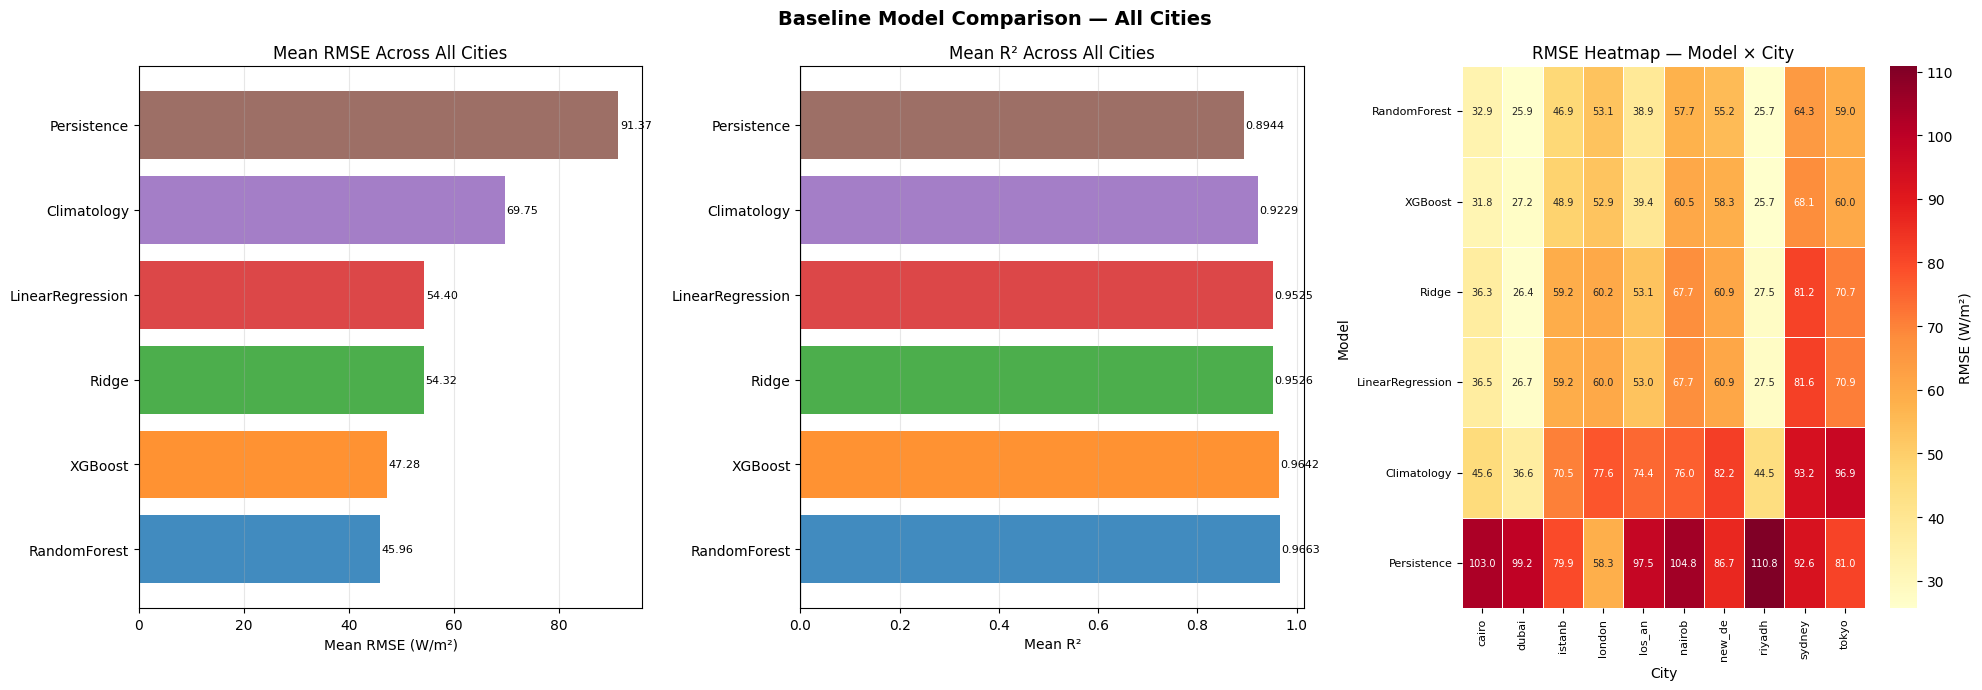

💾 Saved → ..\outputs/plots\06_baseline_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Baseline Model Comparison — All Cities",
    fontsize=14, fontweight="bold"
)

model_order = rmse_pivot.index.tolist()
palette     = sns.color_palette("tab10", len(model_order))

# ── RMSE per model (mean across cities) ──────────────────────────
ax = axes[0]
mean_rmse = rmse_pivot["mean_RMSE"]
bars = ax.barh(
    mean_rmse.index, mean_rmse.values,
    color=palette, alpha=0.85
)
ax.set_xlabel("Mean RMSE (W/m²)")
ax.set_title("Mean RMSE Across All Cities")
ax.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, mean_rmse.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=8)

# ── R² per model ─────────────────────────────────────────────────
ax = axes[1]
mean_r2 = r2_pivot["mean_R2"].reindex(model_order)
bars = ax.barh(
    mean_r2.index, mean_r2.values,
    color=palette, alpha=0.85
)
ax.set_xlabel("Mean R²")
ax.set_title("Mean R² Across All Cities")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.3, axis="x")
for bar, val in zip(bars, mean_r2.values):
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)

# ── RMSE heatmap: model × city ────────────────────────────────────
ax = axes[2]
heat_data = rmse_pivot.drop(columns=["mean_RMSE"]).reindex(model_order)
sns.heatmap(
    heat_data, ax=ax,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "RMSE (W/m²)"},
    annot_kws={"size": 7},
    xticklabels=[c[:6] for c in heat_data.columns]
)
ax.set_title("RMSE Heatmap — Model × City")
ax.set_xlabel("City")
ax.set_ylabel("Model")
ax.tick_params(labelsize=8)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "06_baseline_comparison.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

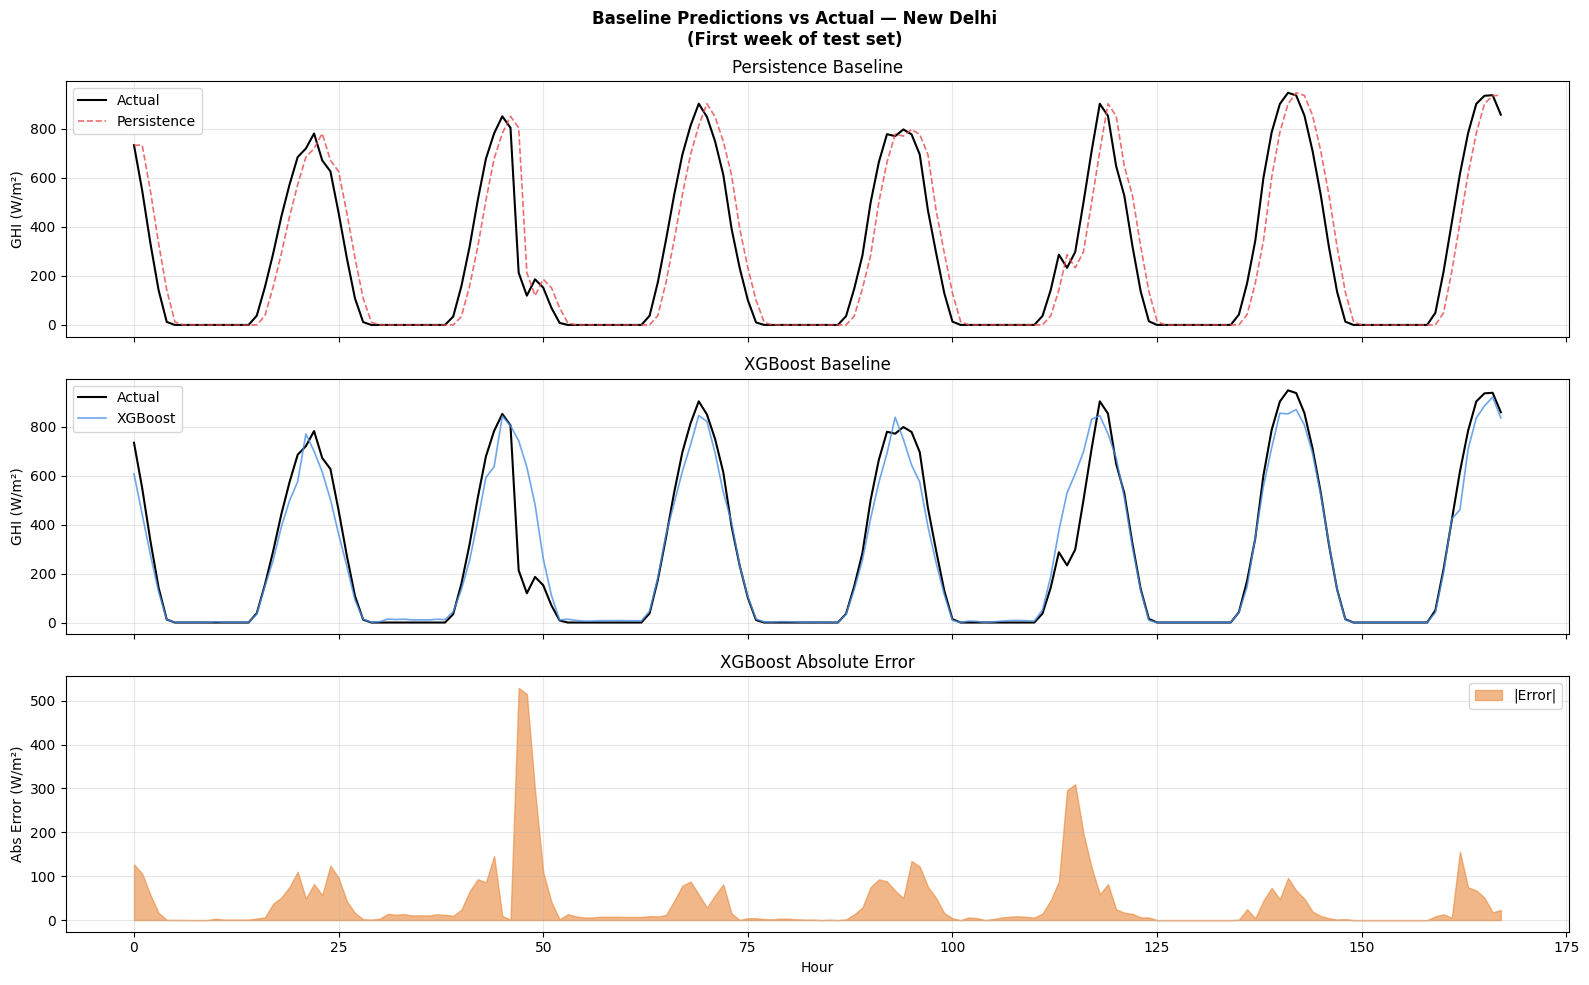

💾 Saved → ..\outputs/plots\06_predictions_vs_actual.png


In [11]:
# Visual check on New Delhi test set
city       = "new_delhi"
df         = city_dfs[city]
_, _, test = chronological_split(df)

X_test, y_test, feats = prepare_Xy(test, SELECTED_FEATURES, TARGET)

# Reload trained XGBoost for this city
xgb_model  = joblib.load(
    os.path.join(MODELS_DIR, f"xgboost_{city}.pkl")
)
xgb_preds  = np.clip(xgb_model.predict(X_test), 0, None)
pers_preds = persistence_baseline(test, TARGET)

# Plot one week
n_plot = 24 * 7
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle(
    f"Baseline Predictions vs Actual — {city.replace('_',' ').title()}"
    f"\n(First week of test set)",
    fontsize=12, fontweight="bold"
)

t = np.arange(n_plot)

axes[0].plot(t, y_test[:n_plot],    color="black",   lw=1.5, label="Actual")
axes[0].plot(t, pers_preds[:n_plot],color="#E84A4A",  lw=1.2,
             linestyle="--", label="Persistence", alpha=0.8)
axes[0].set_ylabel("GHI (W/m²)")
axes[0].set_title("Persistence Baseline")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, y_test[:n_plot],   color="black",   lw=1.5, label="Actual")
axes[1].plot(t, xgb_preds[:n_plot],color="#4A90E8",  lw=1.2,
             label="XGBoost", alpha=0.8)
axes[1].set_ylabel("GHI (W/m²)")
axes[1].set_title("XGBoost Baseline")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

error = np.abs(xgb_preds[:n_plot] - y_test[:n_plot])
axes[2].fill_between(t, 0, error, color="#E8883A", alpha=0.6, label="|Error|")
axes[2].set_ylabel("Abs Error (W/m²)")
axes[2].set_xlabel("Hour")
axes[2].set_title("XGBoost Absolute Error")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "06_predictions_vs_actual.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [12]:
print("=" * 65)
print("  NOTEBOOK 06 — COMPLETE")
print("=" * 65)

print(f"\n  📊 Best model by mean RMSE:")
best = rmse_pivot["mean_RMSE"].idxmin()
print(f"     {best}  →  {rmse_pivot.loc[best,'mean_RMSE']:.3f} W/m²")

print(f"\n  📊 Persistence mean RMSE (our minimum target to beat):")
pers_rmse = rmse_pivot.loc["Persistence", "mean_RMSE"]
print(f"     Persistence  →  {pers_rmse:.3f} W/m²")

print(f"\n  📊 Skill score of best ML model vs persistence:")
skill = (1 - rmse_pivot.loc[best, "mean_RMSE"] / pers_rmse) * 100
print(f"     Skill score  →  {skill:.1f}%  improvement over persistence")

print(f"\n  💾 Files saved:")
print(f"     {results_path}")
for city in CITIES:
    for m in ["xgboost", "lightgbm", "randomforest"]:
        p = os.path.join(MODELS_DIR, f"{m}_{city}.pkl")
        if os.path.exists(p):
            print(f"     {p}")

print(f"\n  🎯 Target for LSTM + NeuroSpike:")
print(f"     Must beat XGBoost RMSE of "
      f"{rmse_pivot.loc['XGBoost','mean_RMSE']:.3f} W/m²")
print(f"\n  Ready for → 07_lstm_model.ipynb")

  NOTEBOOK 06 — COMPLETE

  📊 Best model by mean RMSE:
     RandomForest  →  45.960 W/m²

  📊 Persistence mean RMSE (our minimum target to beat):
     Persistence  →  91.373 W/m²

  📊 Skill score of best ML model vs persistence:
     Skill score  →  49.7%  improvement over persistence

  💾 Files saved:
     ..\outputs/metrics\baseline_results.csv
     ..\models/saved\xgboost_riyadh.pkl
     ..\models/saved\randomforest_riyadh.pkl
     ..\models/saved\xgboost_cairo.pkl
     ..\models/saved\randomforest_cairo.pkl
     ..\models/saved\xgboost_istanbul.pkl
     ..\models/saved\randomforest_istanbul.pkl
     ..\models/saved\xgboost_new_delhi.pkl
     ..\models/saved\randomforest_new_delhi.pkl
     ..\models/saved\xgboost_dubai.pkl
     ..\models/saved\randomforest_dubai.pkl
     ..\models/saved\xgboost_london.pkl
     ..\models/saved\randomforest_london.pkl
     ..\models/saved\xgboost_sydney.pkl
     ..\models/saved\randomforest_sydney.pkl
     ..\models/saved\xgboost_tokyo.pkl
     ..\mod